## Extreme Value Analysis ##
In this Script we will perform Extreme Value Analysis.

The Research Questions answered in this script are:
-  Has the frequency and intensity of extreme events (e.g., heatwaves, heavy precipitation)
increased between 1990 and 2025?
- Have pollen concentrations and the timing of pollen seasons (beginning, peak, duration)
changed over the same period?

We will look at the following outcome variables:

Environmental Variables:
- (Air) Temperature
- Precipitation
- Radiation

Pollen:
- Erle
- Birche
- Hasel
- Buche
- Gemeine Esche
- Eiche
- Gräser

We will limit ourselves to the summer months for now, because our interest lies mainly in the pollen concentrations and extreme events that are more common in summer (very high radiation, temperature, etc.)

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# enable inline plotting
%matplotlib inline 

# We quickly take a look at the dataframe 'df' (nan's are filled with 0)
df = pd.read_parquet("cleaned_data.parquet")
pollen_names = ['Birke', 'Hasel', 'Buche', 'Gemeine Esche', 'Eiche', 'Gräser']
print(df.head())

                     temp_mean  temp_max  temp_min  soil_temp_5cm  \
reference_timestamp                                                 
1990-01-01                -6.1       0.0     -10.0           -0.2   
1990-01-02                -6.5      -1.3     -10.5           -0.3   
1990-01-03                -4.9       1.5      -8.8           -0.3   
1990-01-04                -5.3       2.3     -10.1           -0.4   
1990-01-05                -5.5       0.5      -9.7           -0.5   

                     rel_humidity  tot_precipitation  windspeed  \
reference_timestamp                                               
1990-01-01                   55.4                0.0        0.4   
1990-01-02                   57.8                0.0        0.9   
1990-01-03                   64.1                0.0        0.7   
1990-01-04                   49.9                0.0        1.1   
1990-01-05                   49.7                0.0        1.2   

                     glob_radiation  sunshine_

In [2]:
# Sorting data frame by seasonality
def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

# add season column to dataframe (1 -> "winter", 4 -> "spring", ...)
df["season"] = df.index.month.map(get_season)

# divide into seasons
winter = df[df["season"] ==  "winter"]
spring = df[df["season"] ==  "spring"]
summer = df[df["season"] ==  "summer"]
autumn = df[df["season"] == "autumn"]

print(df.columns)

print(df["season"])

Index(['temp_mean', 'temp_max', 'temp_min', 'soil_temp_5cm', 'rel_humidity',
       'tot_precipitation', 'windspeed', 'glob_radiation', 'sunshine_duration',
       'erle_pollen', 'birke_pollen', 'hasel_pollen', 'buche_pollen',
       'gemeine_esche_pollen', 'eiche_pollen', 'graeser_pollen', 'season'],
      dtype='str')
reference_timestamp
1990-01-01    winter
1990-01-02    winter
1990-01-03    winter
1990-01-04    winter
1990-01-05    winter
               ...  
2025-12-27    winter
2025-12-28    winter
2025-12-29    winter
2025-12-30    winter
2025-12-31    winter
Name: season, Length: 13149, dtype: str


### Extreme Heat Events ###
For now, we will only look at extreme heat events due to time reasons, but one could also look at extreme cold events. We will look at air temperature (not soil temperature).

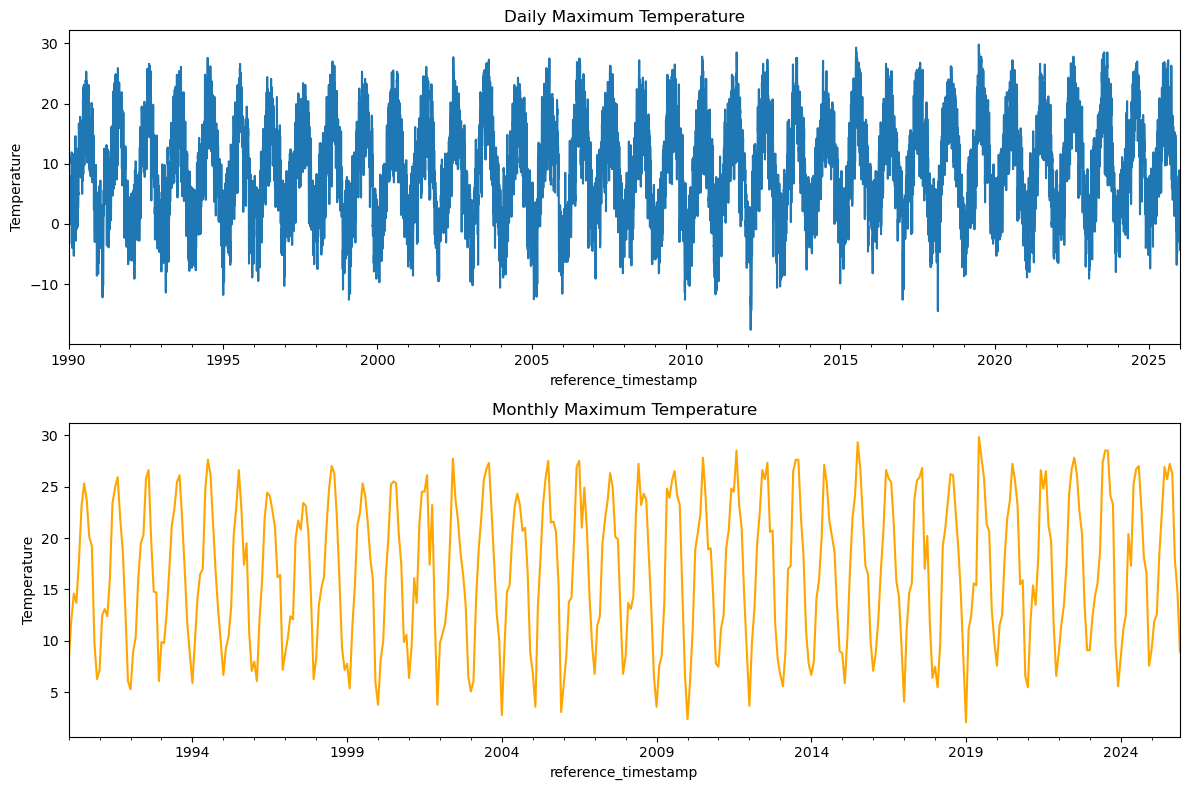

In [3]:
# Visualize the data (maxima per month and maxima per day)

daily_max = df["temp_max"]

monthly_max = df["temp_max"].resample("ME").max()

# Plot both
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

daily_max.plot(ax=axes[0], title="Daily Maximum Temperature")
axes[0].set_ylabel("Temperature")

monthly_max.plot(ax=axes[1], title="Monthly Maximum Temperature", color="orange")
axes[1].set_ylabel("Temperature")

plt.tight_layout()
plt.show()

We see the seasonality in the data. There might be a slight trend towards higher temperatures, but it is hard to see from these plots alone.

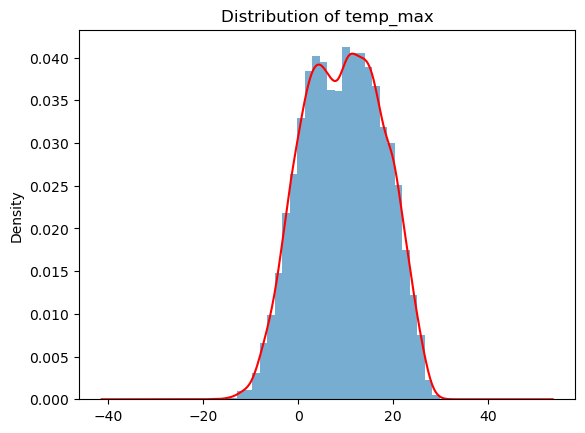

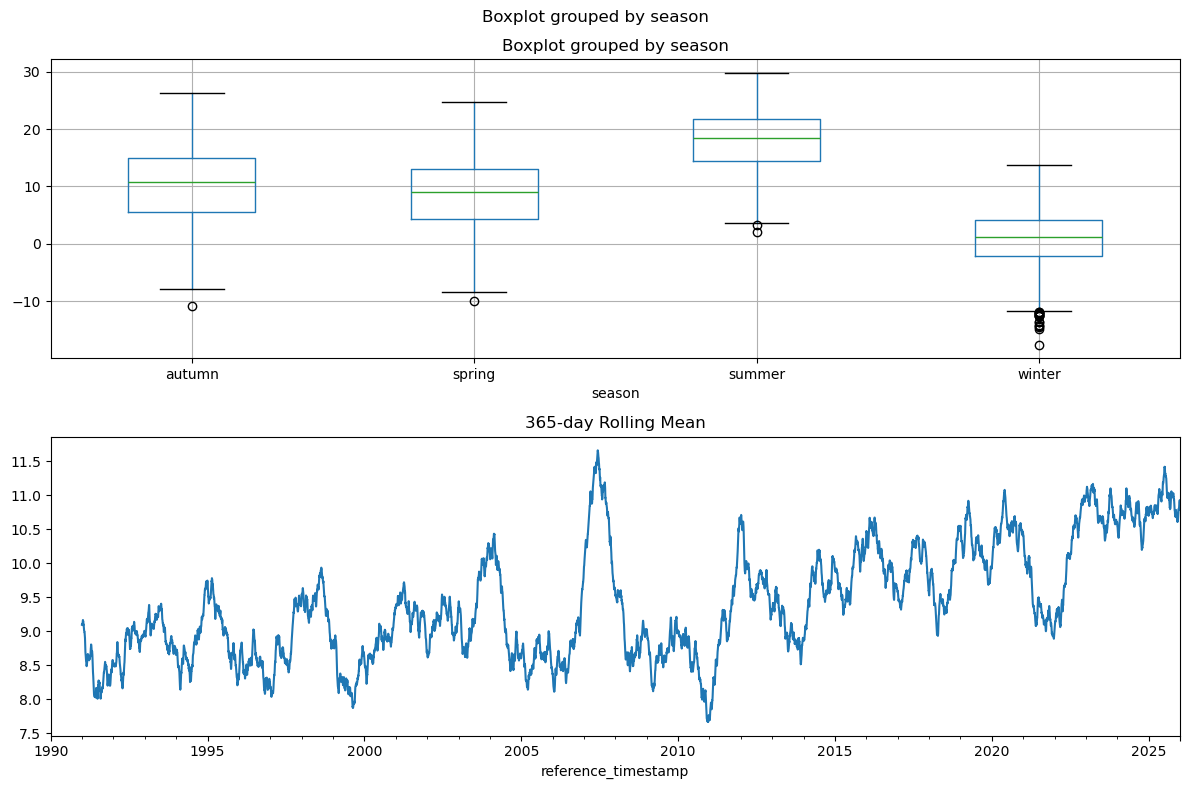

count    13149.000000
mean         9.423804
std          8.233714
min        -17.600000
25%          3.000000
50%          9.600000
75%         15.800000
max         29.800000
Name: temp_max, dtype: float64
Skewness: -0.050
Kurtosis: -0.755


In [4]:
# Histogram + KDE to get a feel for the distribution
daily_max.plot(kind="hist", bins=30, density=True, alpha=0.6, title="Distribution of temp_max")
daily_max.plot(kind="kde", color="red")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

df.boxplot(column="temp_max", by="season", ax=axes[0])
axes[0].set_title("Boxplot grouped by season")

daily_max.rolling(window=365).mean().plot(ax=axes[1], title="365-day Rolling Mean")

plt.tight_layout()
plt.show()


# basic stats
print(daily_max.describe())
print(f"Skewness: {daily_max.skew():.3f}")
print(f"Kurtosis: {daily_max.kurt():.3f}")


Observations:
- a bit of a bimodal distribution (makes sense due to seasonality -> cold in winter, warmer in summer) -> also nicely visible in the boxplot
- the rolling mean shows an upward tendency in the temperature
- very slight skewness
- kurtosis negative -> flatter, lower peak and lighter, thinner tails compared to a normal distribution 

To get an idea of possible trends, we will first split the data into two blocks (1990-2007 and 2008 - 2025) and fit a GEV to each period. This will show us if the distribution of extreme events has changed between these two time periods.

Period 1 —> loc: 15.01, scale: 7.37, shape: 0.54
Period 2 —> loc: 15.65, scale: 7.86, shape: 0.53


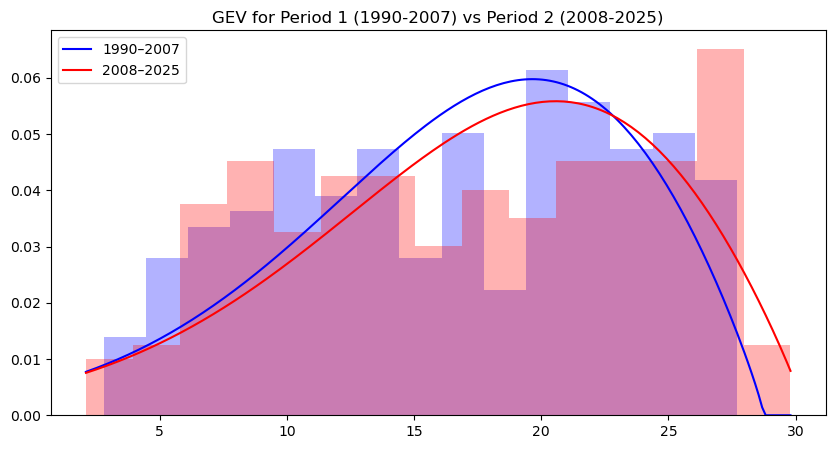

In [5]:
# split the data
period1 = monthly_max["1990":"2007"]
period2 = monthly_max["2008":"2025"]

# Fit a GEV to each period
from scipy.stats import genextreme

# no need to drop NAs, because we already took care of this in the data preparation
# Fit GEV (shape, loc, scale)
shape1, loc1, scale1 = genextreme.fit(period1)
shape2, loc2, scale2 = genextreme.fit(period2)

print(f"Period 1 —> loc: {loc1:.2f}, scale: {scale1:.2f}, shape: {shape1:.2f}")
print(f"Period 2 —> loc: {loc2:.2f}, scale: {scale2:.2f}, shape: {shape2:.2f}")


# Plot
x = np.linspace(monthly_max.min(), monthly_max.max(), 200)

plt.figure(figsize=(10, 5))
# probability density functions
plt.plot(x, genextreme.pdf(x, shape1, loc1, scale1), label="1990–2007", color="blue")
plt.plot(x, genextreme.pdf(x, shape2, loc2, scale2), label="2008–2025", color="red")

# histogram behind it
plt.hist(period1, bins=15, density=True, alpha=0.3, color="blue")
plt.hist(period2, bins=15, density=True, alpha=0.3, color="red")

plt.legend()
plt.title("GEV for Period 1 (1990-2007) vs Period 2 (2008-2025)")
plt.show()

Observations:

- Location increased a little (from 15.01 to 15.64) -> the "typical" monthly maximum shifted upward, consistent with warming
- Scale increased as well -> extreme values are a bit more variableu
- Shape barely changed -> visually both Frechet with a heavy tail (0.54 to 0.53 -> no big change here)
- red curve has more "mass" towards higher temperatures (since it's shifted a bit more to the right than the blue curve)

Period 1 — loc: 24.23, scale: 2.06, shape: 0.54
Period 2 — loc: 25.63, scale: 1.73, shape: 0.36


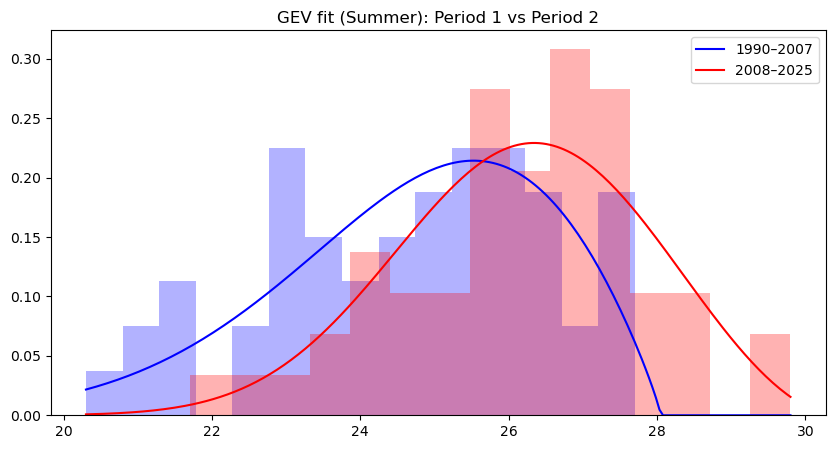

In [6]:
# We do the same as above but now just restricting to summer months

summer_max = monthly_max[monthly_max.index.month.isin([6, 7, 8])]

period1 = summer_max["1990":"2007"]
period2 = summer_max["2008":"2025"]

# Fit a GEV to each period
from scipy.stats import genextreme

# Fit GEV (returns shape, loc, scale)
shape1, loc1, scale1 = genextreme.fit(period1.dropna())
shape2, loc2, scale2 = genextreme.fit(period2.dropna())

print(f"Period 1 — loc: {loc1:.2f}, scale: {scale1:.2f}, shape: {shape1:.2f}")
print(f"Period 2 — loc: {loc2:.2f}, scale: {scale2:.2f}, shape: {shape2:.2f}")

# Plot
x = np.linspace(summer_max.min(), summer_max.max(), 200)

plt.figure(figsize=(10, 5))
plt.plot(x, genextreme.pdf(x, shape1, loc1, scale1), label="1990–2007", color="blue")
plt.plot(x, genextreme.pdf(x, shape2, loc2, scale2), label="2008–2025", color="red")
plt.hist(period1.dropna(), bins=15, density=True, alpha=0.3, color="blue")
plt.hist(period2.dropna(), bins=15, density=True, alpha=0.3, color="red")
plt.legend()
plt.title("GEV fit (Summer): Period 1 vs Period 2")
plt.show()

Observations (Summer):
- red curve is shifted to the right -> summer extreme temperatures are higher in 2008-2025 than in the earlier period, therefore extreme heat has intensified
- red peaks at higher temperature values than blue -> typical extreme temp is hotter now
- red's right tail extends further and the curve has more mass over the high-temperature region -> extra extreme temperatures are more attainable nowadays
- the shape of blue and red curve has changed (0.54 -> 0.36)

 => overall, we see an increase in intensity of extreme heat (due to the higher maxima and stretched out right tail) and an overall warming of extreme values, which is consistent with climate change. There's still a strong overlap between both periods, however the shift and the particularly ponounced change in the right tail is quite significant.

Period 1 — loc: 6.89, scale: 2.33, shape: 0.26
Period 2 — loc: 7.24, scale: 2.56, shape: 0.33


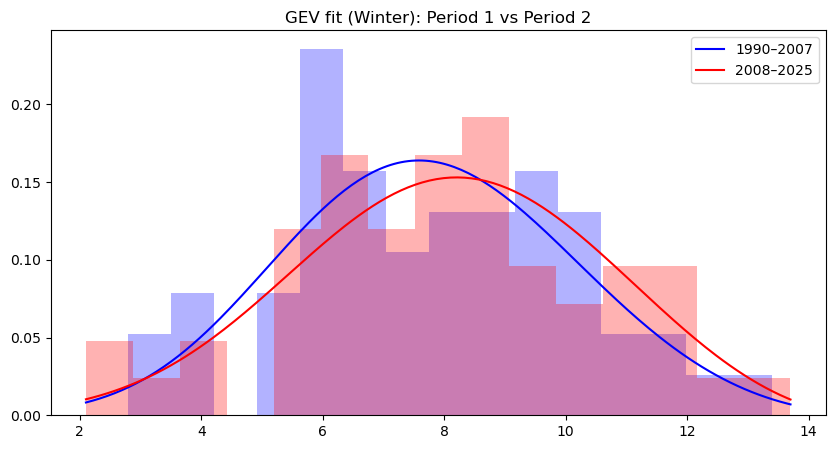

In [7]:
# Repeat code but with winter months instead

winter_max = monthly_max[monthly_max.index.month.isin([12, 1, 2])]

period1 = winter_max["1990":"2007"]
period2 = winter_max["2008":"2025"]

# Fit a GEV to each period
from scipy.stats import genextreme

# Fit GEV (returns shape, loc, scale)
shape1, loc1, scale1 = genextreme.fit(period1.dropna())
shape2, loc2, scale2 = genextreme.fit(period2.dropna())

print(f"Period 1 — loc: {loc1:.2f}, scale: {scale1:.2f}, shape: {shape1:.2f}")
print(f"Period 2 — loc: {loc2:.2f}, scale: {scale2:.2f}, shape: {shape2:.2f}")

# Plot
x = np.linspace(winter_max.min(), winter_max.max(), 200)

plt.figure(figsize=(10, 5))
plt.plot(x, genextreme.pdf(x, shape1, loc1, scale1), label="1990–2007", color="blue")
plt.plot(x, genextreme.pdf(x, shape2, loc2, scale2), label="2008–2025", color="red")
plt.hist(period1.dropna(), bins=15, density=True, alpha=0.3, color="blue")
plt.hist(period2.dropna(), bins=15, density=True, alpha=0.3, color="red")
plt.legend()
plt.title("GEV fit (Winter): Period 1 vs Period 2")
plt.show()

Observations (Winter):
Note that we are looking at the winter monthly MAXIMA, so we're not looking at cold extremes. 
So to check for a change in extreme temperatures in the winter, we'd need to look at the MINIMA. 

- red curve is slightly shifted to the right -> winters are milder and max temp is higher in 2008-2025 than in the previous period
- red curve has lower maximum and is spread slightly wider -> more variability and possible fluctuations between cold and milder days
- shape of blue and red curve has changed slightly (0.26 -> 0.33)

=> In the last 20 years, the winters have become slightly milder than before, with a higher typical temperature and a higher range of temperature fluctuations. Nontheless, the overlap is still quite strong so there isn't a that big of a change than in the summer, but the change is still moderate.

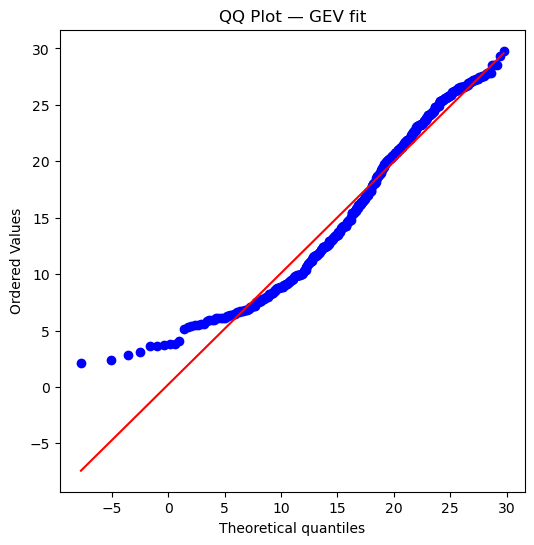

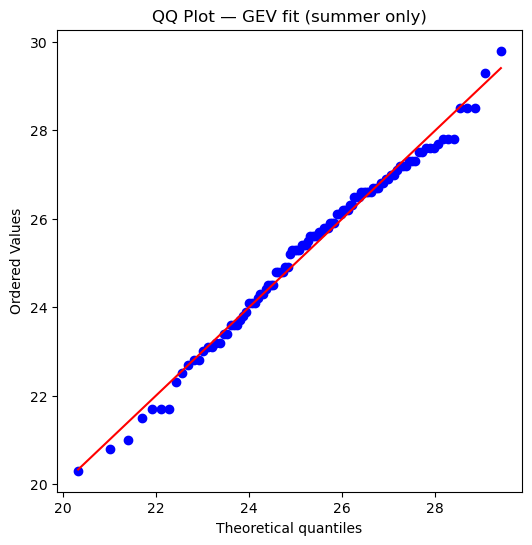

In [8]:
# Quick validation that the distribution and model choice is ok

from scipy import stats

# For GEV (monthly maxima)
shape, loc, scale = genextreme.fit(monthly_max.dropna()) # EDIT: cell was outputting error
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(monthly_max.dropna(), dist=stats.genextreme, 
               sparams=(shape, loc, scale), plot=ax)
ax.set_title("QQ Plot — GEV fit")
plt.show()


summer_monthly_max = df[df["season"] == "summer"]["temp_max"].resample("ME").max().dropna()

shape, loc, scale = genextreme.fit(summer_monthly_max)

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(summer_monthly_max, dist=stats.genextreme,
               sparams=(shape, loc, scale), plot=ax)
ax.set_title("QQ Plot — GEV fit (summer only)")
plt.show()

For the whole year the QQ plot is not optimal (poor fit, mainly at the lower tail). But for the summer it looks alright. Because we are mainly focused on the extremes in summer, we will accept this for now. In a more rigorous analysis, we might also fit the model only to the summer months to have a more precise window to look at heatwaves.

In [9]:
# Because we do not have sationary data (with climate change, we assume that the climate is getting warmer which is also shown in the exploratory part just above). 
# Therefore, we need to let the location (average) vary linearily in time.
# If mu is significantly different from zero = there's a real trend in extremes.

from scipy.stats import genextreme
from scipy.optimize import minimize

# Create time covariate (0, 1, 2, ... for each month) = represents time passing
t = np.arange(len(monthly_max)) # = time variable
y = monthly_max.values

# Define non-stationary GEV log-likelihood
# mu = mu0 + mu1 * t  (location varies with time), while scale and shape stay constant
# goal: find the parameters
def neg_log_likelihood(params): # Defines a function that takes a list of 4 parameters as input.
    mu0, mu1, scale, shape = params # unpack the parameters
    if scale <= 0: # scale cant be negative
        return np.inf
    mu = mu0 + mu1 * t # computes the shifting location of mu with time
    return -np.sum(genextreme.logpdf(y, c=shape, loc=mu, scale=scale)) 
    # asks: given our current parameters, how probable is this observation? -> returns a prob score (per month), the np.sum, sums up these scores, flip the sign, because later minimize looks for the lowest number, but we want the highest probability. 


# Initial guess from stationary fit
shape0, loc0, scale0 = genextreme.fit(y)

# need to manually implement MLE using an optimization algorithm (Nelder-Mead), since genextreme.fit() doesn't support non-stationary models
result = minimize(
    neg_log_likelihood,
    x0=[loc0, 0, scale0, shape0], # starting points from the stationary fit and mu1 = 0 (no trend assumed)
    method="Nelder-Mead"
)

mu0, mu1, scale, shape = result.x
print(f"mu0 (intercept): {mu0:.3f}")
print(f"mu1 (trend):     {mu1:.4f} ")
print(f"scale:           {scale:.3f}")
print(f"shape:           {shape:.3f}")

print(f"Trend per year:   {mu1 * 12:.3f} °C/year")
print(f"Trend over 35 years: {mu1 * 12 * 35:.3f} °C")

mu0 (intercept): 14.067
mu1 (trend):     0.0059 
scale:           7.616
shape:           0.536
Trend per year:   0.071 °C/year
Trend over 35 years: 2.479 °C


In [10]:
# Fit stationary model (mu1 = 0) for comparison
# Hypothesis Test: Compare the model (non-stationary GEV) to the NULL-Model (stationary GEV)

# Likelihood ratio test (GEV equivalent of ANOVA)
def neg_log_likelihood_stat(params): # EDIT: cell wouldn't run otherwise
    mu0, scale, shape = params
    if scale <= 0:
        return np.inf
    return -np.sum(genextreme.logpdf(y, c=shape, loc=mu0, scale=scale))

result_stat = minimize( 
    neg_log_likelihood_stat,
    x0=[loc0, scale0, shape0],
    method="Nelder-Mead"
)

LR = 2 * (result_stat.fun - result.fun) 
#result_stat.fun = the minimum negative log-likelihood of the stationary model
# result.fun = the minimum negative log-likelihood of the non-stationary model
# multiplication with two makes it follow a chi-squared distribution

from scipy.stats import chi2
p_value = chi2.sf(LR, df=1)  
# sf (survival function): P(X > x) -> probability of getting a value more extreme than x
# 1 extra parameter in non-stationary model because of mu1
print(f"LR statistic: {LR:.3f}")
print(f"p-value:      {p_value:.4f}")

LR statistic: 7.636
p-value:      0.0057


Summer 95th percentile threshold: 25.4°C
reference_timestamp
1990     0
1991     1
1992     5
1993     1
1994     2
1995     2
1996     0
1997     0
1998     5
1999     0
2000     1
2001     1
2002     2
2003    12
2004     0
2005     3
2006    10
2007     3
2008     1
2009     2
2010     6
2011     5
2012     7
2013     8
2014     3
2015    17
2016     3
2017     4
2018     6
2019    12
2020     4
2021     2
2022     8
2023    10
2024     5
2025    10
Name: temp_max, dtype: int64


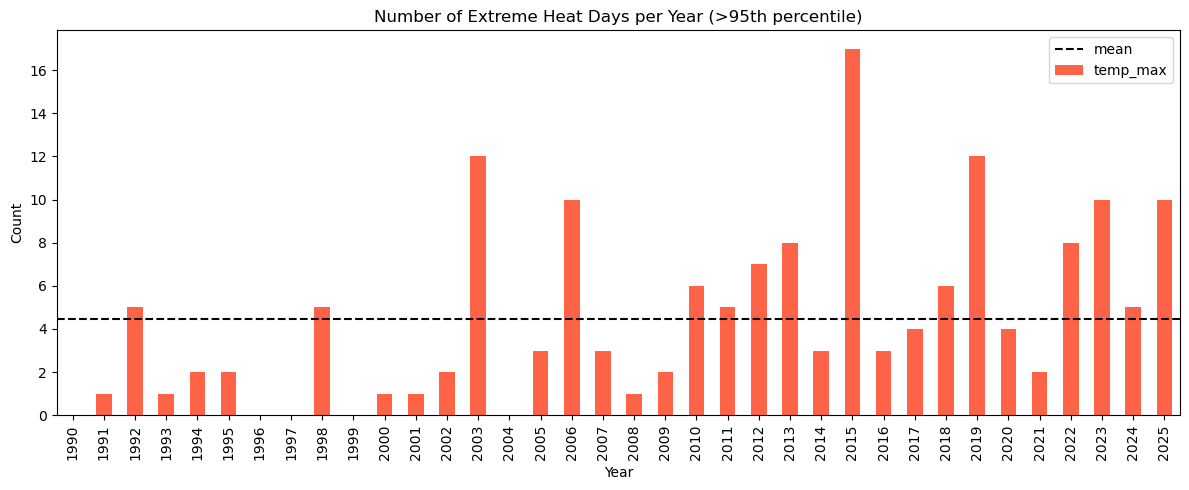

In [11]:
# 95th percentile over summer months
# determining 95th percentile of daily max temperature
summer_days = df[df["season"] == "summer"]["temp_max"] # filter only summer days
threshold = summer_days.quantile(0.95) # 95% quantile for summer days
print(f"Summer 95th percentile threshold: {threshold:.1f}°C")

# Count extreme heat days
extreme_days = summer_days[summer_days > threshold]

# Count per year
extreme_days_per_year = extreme_days.resample("YE").count() # group by year and count how many per year
extreme_days_per_year.index = extreme_days_per_year.index.year  # convert datetime index to integers (needed for reindex, which uses integers)
extreme_days_per_year = extreme_days_per_year.reindex(range(1990, 2026), fill_value=0)  # to not loose the years with 0 extreme days

# print how many extreme days we had per year
print(extreme_days_per_year)

# plot
plt.figure(figsize=(12, 5))
extreme_days_per_year.plot(kind="bar", color="tomato")
plt.axhline(extreme_days_per_year.mean(), color="black", linestyle="--", label="mean") # draws line at mean (reference)
plt.title("Number of Extreme Heat Days per Year (>95th percentile)")
plt.ylabel("Count")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


Observations:
- Early years (1990s): mostly below the mean, several very low years
- Last 10 years: almost consistently above or close to the mean
- Notable spike years: 2003, 2006, 2015, 2023 -> all well-known extreme summers

In [12]:
# Use Mann-Kendall Test to test for signficance (because we don't want to assume normality, because we have count data here, plus robust to outliers and often used on climate research)
import pymannkendall as mk

result = mk.original_test(extreme_days_per_year)

print(f"Trend:     {result.trend}")
print(f"P-value:   {result.p:.4f}")
print(f"Slope:     {result.slope:.4f} days/year")
print(f"Trend over 35 years: {result.slope * 35:.1f} extra extreme days")

Trend:     increasing
P-value:   0.0001
Slope:     0.1875 days/year
Trend over 35 years: 6.6 extra extreme days


Observations:
- The number of extreme heat days (>22.6°C) has been significantly increasing (p-value <  0.0001)
- at a rate of roughly 0.1875 days per year
- From 1990 to 2025, this means an increase of 6-7 days with extreme temperatures (over 25.4°C).

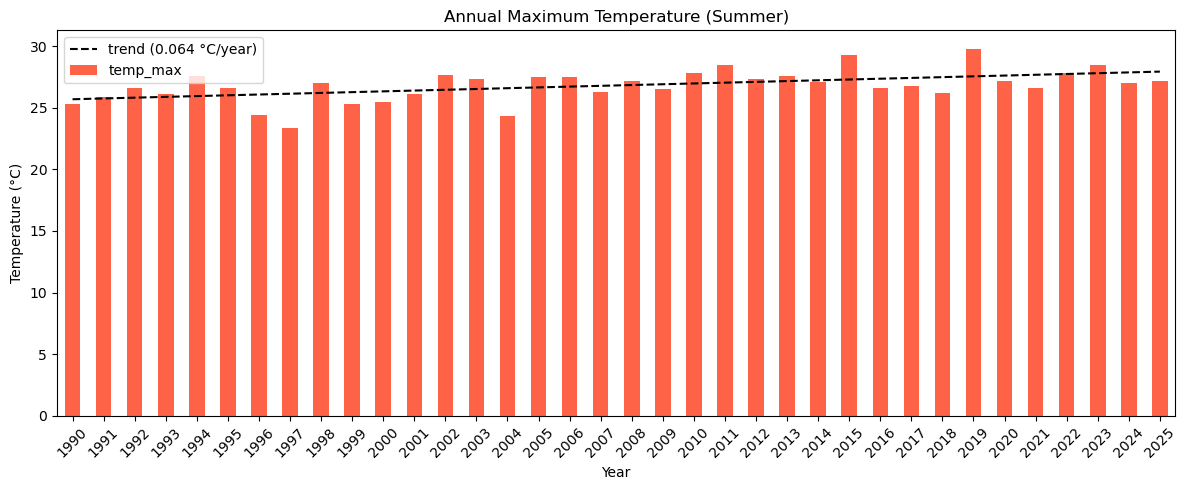

Trend:     increasing
P-value:   0.0032
Slope:     0.0583 °C/year
Trend over 35 years: 2.04 °C


In [13]:
# Annual maximum temperature
annual_max = summer_days.resample("YE").max()
annual_max.index = annual_max.index.year

plt.figure(figsize=(12, 5))
annual_max.plot(kind="bar", color="tomato")

# trend line
x = np.arange(len(annual_max))
z = np.polyfit(x, annual_max.values, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color="black", linestyle="--", label=f"trend ({z[0]:.3f} °C/year)")

plt.title("Annual Maximum Temperature (Summer)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

result_mk = mk.original_test(annual_max)
print(f"Trend:     {result_mk.trend}")
print(f"P-value:   {result_mk.p:.4f}")
print(f"Slope:     {result_mk.slope:.4f} °C/year")
print(f"Trend over 35 years: {result_mk.slope * 35:.2f} °C")

Observations:
- there is a clear upward trend in the annual maximum temperature in summer
- this increasing trend is signifcant (p-value = 0.0032)
- We see an increase of 0.0583 °C/year
- over 35 years the extreme annual temperature have increased around 2.04°C

### Pollen ###

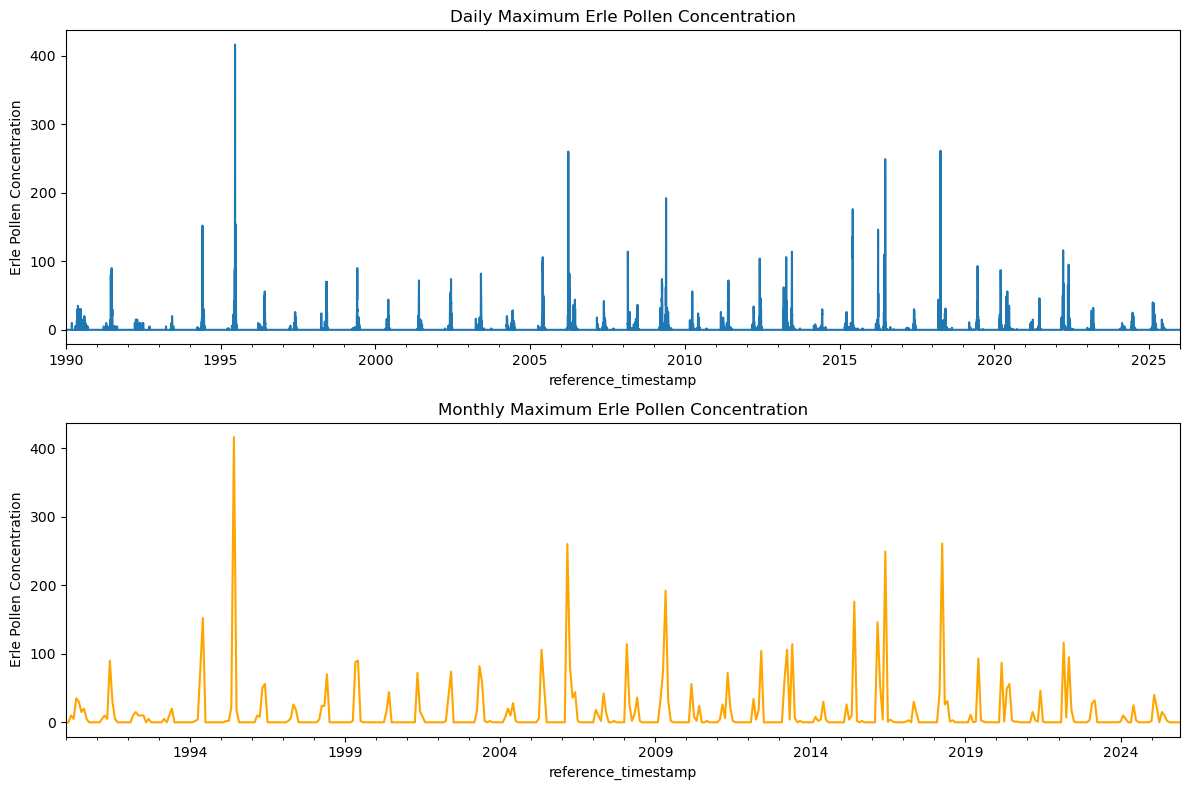

In [14]:
# Visualize the data (maxima per month and maxima per day)
# We start with Erle Pollen

daily_erle = df["erle_pollen"]

monthly_max_erle = df["erle_pollen"].resample("ME").max()

# Plot both
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

daily_erle.plot(ax=axes[0], title="Daily Maximum Erle Pollen Concentration")
axes[0].set_ylabel("Erle Pollen Concentration")

monthly_max_erle.plot(ax=axes[1], title="Monthly Maximum Erle Pollen Concentration", color="orange")
axes[1].set_ylabel("Erle Pollen Concentration")

plt.tight_layout()
plt.show()

This already shows that because there is such strong seasonality for pollen (no pollen at all during winter), it makes sense to take the months, where the different pollens are most abundant. This needs to be defined for each of the different pollen types separately.

- Erle: January - June
- Gräser: April - September

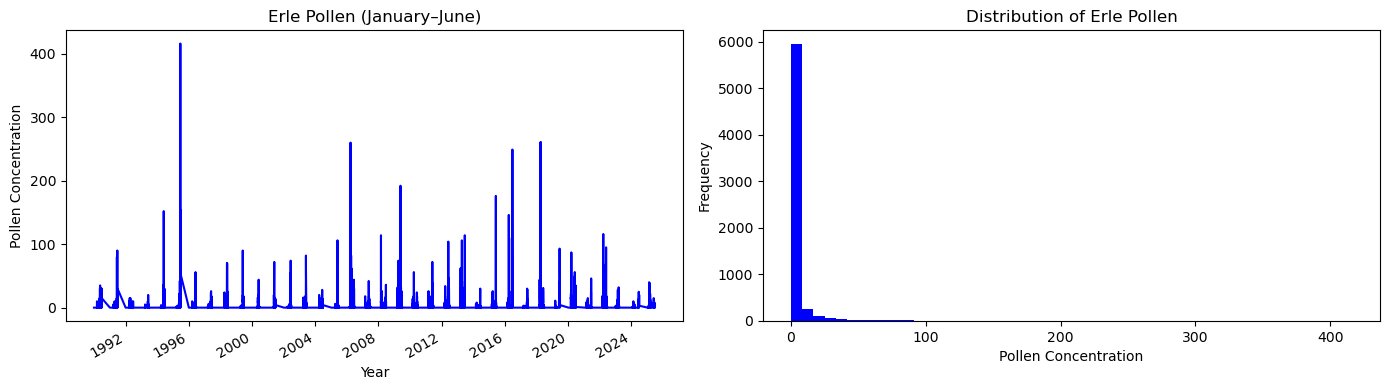

count    6525.000000
mean        3.295326
std        14.307540
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       416.000000
Name: erle_pollen, dtype: float64
Skewness: 11.384
Kurtosis: 201.736


In [15]:
# Filter to pollen seasons
erle_season = df[df.index.month.isin([1, 2, 3, 4, 5, 6])]["erle_pollen"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
erle_season.plot(ax=axes[0], title="Erle Pollen (January–June)", color="blue")
axes[0].set_ylabel("Pollen Concentration")
axes[0].set_xlabel("Year")

# Histogram to see the distribution
erle_season.plot(kind="hist", ax=axes[1], bins=50, color="blue", title="Distribution of Erle Pollen")
axes[1].set_xlabel("Pollen Concentration")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Numeric summary
print(erle_season.describe())
print(f"Skewness: {erle_season.skew():.3f}")
print(f"Kurtosis: {erle_season.kurt():.3f}")

Observations:
- We can see that we still have a strongly right skewed distribution with a lot of 0 values
- It seems that even during the high season, only a few days have strong pollen concentrations
- mean = 3.3, max = 416, with up to 75% being 0
- The high skewness (11.4) and kurtosis (201.7) confirm extremely heavy tails -> makes EVA particularly appropriate for this data
- 1996 seems very extreme, might be an outlier

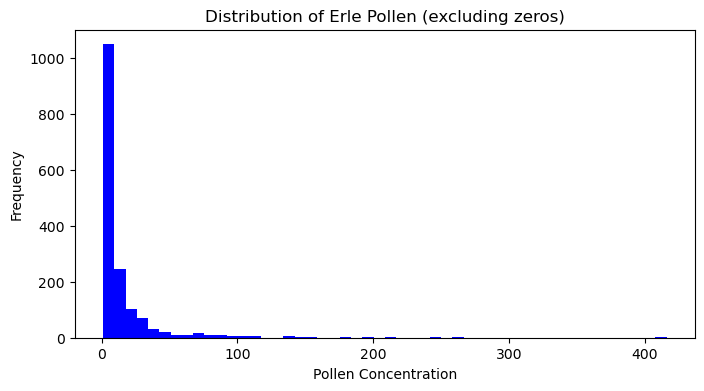

Non-zero days: 1606 out of 6525 (24.6%)


In [16]:
# plot non zero days:
erle_nonzero = erle_season[erle_season > 0]
erle_nonzero.plot(kind="hist", bins=50, color="blue",title="Distribution of Erle Pollen (excluding zeros)", figsize=(8, 4))
plt.xlabel("Pollen Concentration")
plt.ylabel("Frequency")
plt.show()

print(f"Non-zero days: {len(erle_nonzero)} out of {len(erle_season)} ({len(erle_nonzero)/len(erle_season)*100:.1f}%)")
# only around 25% are non-zero values even after only including the season months

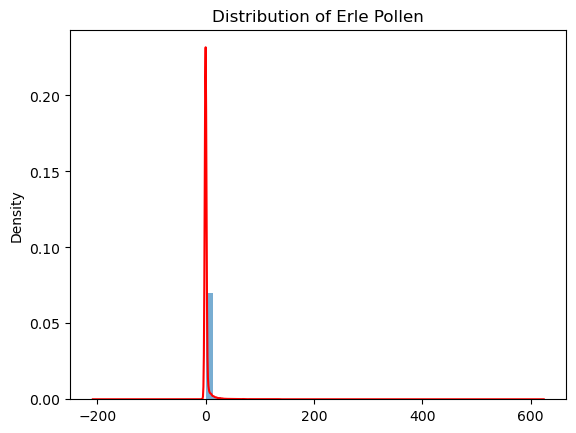

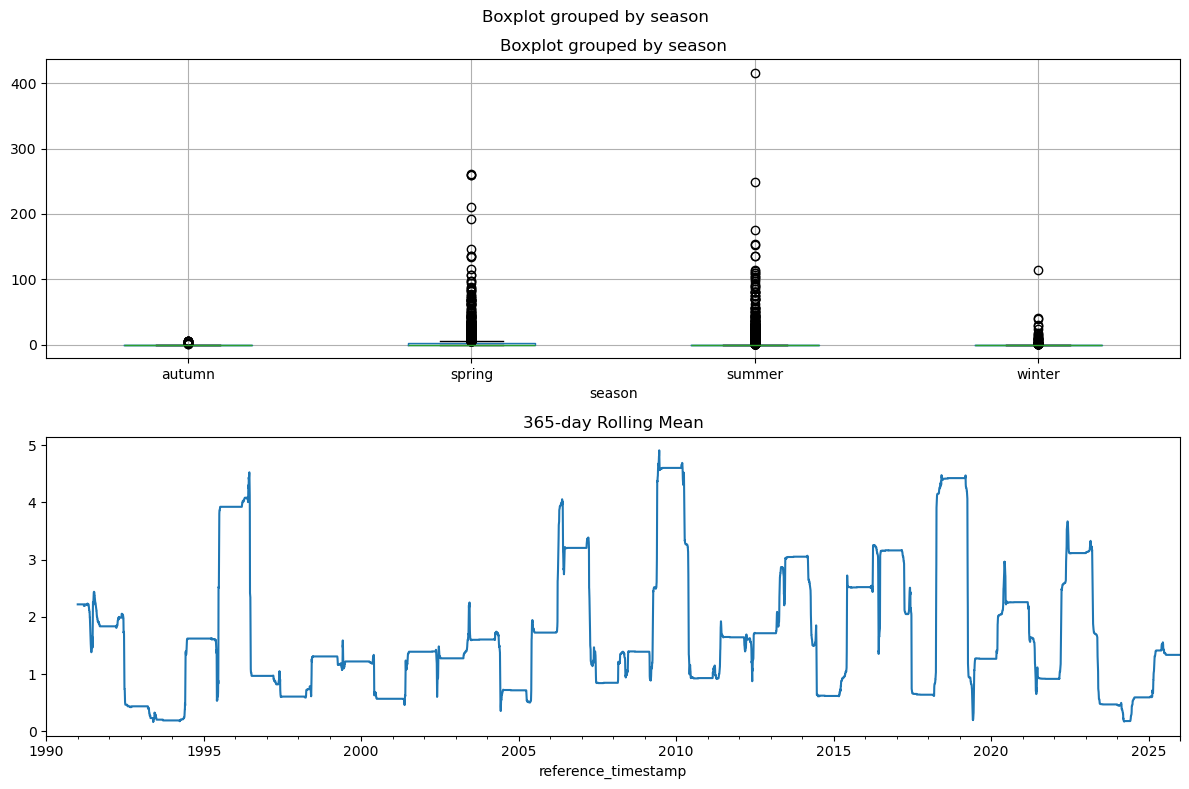

count    13149.000000
mean         1.675184
std         10.224398
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        416.000000
Name: erle_pollen, dtype: float64
Skewness: 15.942
Kurtosis: 396.334


In [17]:
# Histogram + KDE to get a feel for the distribution
daily_erle.plot(kind="hist", bins=30, density=True, alpha=0.6, title="Distribution of Erle Pollen")
daily_erle.plot(kind="kde", color="red")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

df.boxplot(column="erle_pollen", by="season", ax=axes[0])
axes[0].set_title("Boxplot grouped by season")

daily_erle.rolling(window=365).mean().plot(ax=axes[1], title="365-day Rolling Mean")

plt.tight_layout()
plt.show()


# basic stats
print(daily_erle.describe())
print(f"Skewness: {daily_erle.skew():.3f}")
print(f"Kurtosis: {daily_erle.kurt():.3f}")


not super informative yet because of the many 0s

Period 1 —> loc: 10.90, scale: 12.47, shape: -0.96
Period 2 —> loc: 10.03, scale: 13.40, shape: -1.12


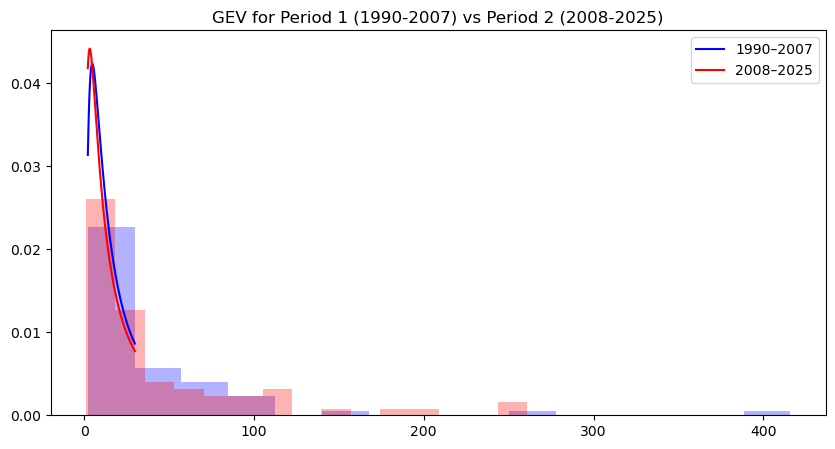

In [18]:
# Use pollen season only and exclude zeros
erle_monthly_max = erle_season.resample("ME").max()

# exclude months with 0 maximum (= no pollen activity that month)
erle_monthly_max = erle_monthly_max[erle_monthly_max > 0]

# split into periods
period1 = erle_monthly_max["1990":"2007"]
period2 = erle_monthly_max["2008":"2025"]


# Fit a GEV to each period
from scipy.stats import genextreme

# no need to drop NAs, because we already took care of this in the data preparation
# Fit GEV (shape, loc, scale)
shape1, loc1, scale1 = genextreme.fit(period1)
shape2, loc2, scale2 = genextreme.fit(period2)

print(f"Period 1 —> loc: {loc1:.2f}, scale: {scale1:.2f}, shape: {shape1:.2f}")
print(f"Period 2 —> loc: {loc2:.2f}, scale: {scale2:.2f}, shape: {shape2:.2f}")


# Plot
x = np.linspace(monthly_max.min(), monthly_max.max(), 200)

plt.figure(figsize=(10, 5))
# probability density functions
plt.plot(x, genextreme.pdf(x, shape1, loc1, scale1), label="1990–2007", color="blue")
plt.plot(x, genextreme.pdf(x, shape2, loc2, scale2), label="2008–2025", color="red")

# histogram behind it
plt.hist(period1, bins=15, density=True, alpha=0.3, color="blue")
plt.hist(period2, bins=15, density=True, alpha=0.3, color="red")

plt.legend()
plt.title("GEV for Period 1 (1990-2007) vs Period 2 (2008-2025)")
plt.show()

Judging from the plots, it seems more appropriate to take a different approach for the pollen data. The data is zero-inflated with extreme outliers and the GEV analysis does not capture this well. Furthermore, the question it answers is scientifically less relevant than other questions. It matters more whether we observe a higher total pollen load over the years, whether the pollen season duration has changed and whether the season is shifting earlier (e.g. earlier flowering due to warming temperatures). Considering that we are examining pollen in the context of ecosystem effects (e.g. phenological mismatch between flowering and pollinators) and human health (e.g. allergy symptoms), we focus on the following questions:

Season start -> Is the flowering season shifting earlier over time?
Season duration -> Is the season getting longer?
Total seasonal load -> Is the total amount of pollen per season increasing?

Next steps:
- define season start (threshold, example 10) -> maybe look up in literature
- Define season end threshold (same or different threshold?)
- Calculate season start, duration and total load per year for Erle and Gräser
- Plot all three metrics over time
- Run Mann-Kendall trend test on each metric
- Interpret results in context of climate change (earlier spring warming → earlier flowering?)

We can define the following:
- season start as the day when cumulative annual pollen reaches 1%
- season end as the day when cumulative annual pollen reaches 95%
- season duration = end - start + 1 (include season start day)
- total load = sum of daily pollen values over a year (area under curve) 
- peak day = day of maximum (argument)
- peak value = maximum daily concentration (y-value)

Observe that the threshold is not fixed for all pollen types but dependent on each. This is the standard definition included in the EAN pollen database: https://pmc.ncbi.nlm.nih.gov/articles/PMC6209030/#Sec4

In [19]:
# Here we define a function for computing the season metrics of pollen

def pollen_season_metrics(series, start_frac=0.01, end_frac=0.95):
    '''
    Input: pollen data, season start (day of 1% total pollen reached) and season end (day of 95% total pollen reached)
    Output: yearly pollen season metrics (start, end, peak day, duration, total load, peak value)
    '''
    results = []

    for year in sorted(series.index.year.unique()): # loop over all years in data chronologically
        s = series[series.index.year == year].copy()
        total = s.sum() # compute total load of that year

        # in case the year has no pollen or only nan's (to avoid division by zero below):
        if total <= 0:
            results.append({
                "year": year,
                "season_start_doy": np.nan,
                "season_peak_doy": np.nan,
                "season_end_doy": np.nan,
                "season_duration_days": np.nan,
                "total_load": 0,
                "peak_value": 0
            })
            continue

        # compute cumulative pollen fraction (in order to determine season start and end)
        cumulative = s.cumsum() / total # vector with (cumsum/total) value for each day

        # define season start, end and peak day
        start_date = cumulative[cumulative >= start_frac].index[0]
        end_date = cumulative[cumulative >= end_frac].index[0]
        peak_date = s.idxmax()

        # add computed values to dictionary
        results.append({
            "year": year,
            "season_start_doy": start_date.dayofyear,
            "season_peak_doy": peak_date.dayofyear,
            "season_end_doy": end_date.dayofyear,
            "season_duration_days": (end_date - start_date).days + 1,
            "total_load": total,
            "peak_value": s.max()
        })

    return pd.DataFrame(results).set_index("year")

In [20]:
# We compute metrics for Erle and Graeser in dataframe
erle_metrics = pollen_season_metrics(df["erle_pollen"], start_frac=0.01, end_frac=0.95)
graeser_metrics = pollen_season_metrics(df["graeser_pollen"], start_frac=0.01, end_frac=0.95)

# Display first 5 rows and last 5 rows of metrics 
print("Metrics for Erle:")
display(erle_metrics.head())
display(erle_metrics.tail())

print("Metrics for Gräser:")
display(graeser_metrics.head())
display(graeser_metrics.tail())


Metrics for Erle:


,season_start_doy,season_peak_doy,season_end_doy,season_duration_days,total_load,peak_value
year,,,,,,
1990,71,143,231,161,810.0,35.0
1991,83,176,184,102,670.0,90.0
1992,84,97,183,100,160.0,15.0
1993,86,158,173,88,70.0,20.0
1994,91,152,169,79,592.0,152.0


,season_start_doy,season_peak_doy,season_end_doy,season_duration_days,total_load,peak_value
year,,,,,,
2021,61,167,171,111,335.0,46.0
2022,62,82,155,94,1137.0,116.0
2023,3,72,79,77,172.0,32.0
2024,28,171,193,166,217.0,25.0
2025,22,44,170,149,488.0,40.0


Metrics for Gräser:


,season_start_doy,season_peak_doy,season_end_doy,season_duration_days,total_load,peak_value
year,,,,,,
1990,122,175,243,122,2955.0,100.0
1991,145,188,234,90,2155.0,110.0
1992,129,137,251,123,1455.0,100.0
1993,131,185,223,93,1205.0,105.0
1994,127,175,209,83,1494.0,76.0


,season_start_doy,season_peak_doy,season_end_doy,season_duration_days,total_load,peak_value
year,,,,,,
2021,134,187,223,90,2450.0,152.0
2022,119,169,208,90,2773.0,112.0
2023,125,144,234,110,3025.0,184.0
2024,122,238,239,118,5126.0,1365.0
2025,118,127,230,113,2411.0,79.0


Observation (Erle):
- season starts around March (day 70-90) with some variation in the '90s and in the 2020's its around January to early March (day 3-60) -> Erle season starts earlier now (due to global warming?)
- season duration also varies (e.g. 161 days in 1990 but only 79 days in 1994, and in 2024: 166 days) -> season length not very stable; might suggest stronger dependence on yearly weather (i.e. temperature and precipitation)
- total load is extremely variable, no clear trend
- peak value is also quite variable, no clear trend

Observation (Graeser):
- season starts around May-June (day 120-145) in 90's and 2020's (slightly earlier in latter period) -> moderate shift toward early onset
- season duration is more stable than for Erle but varies
- total load is much higher than Erle but also varies from year to year (no clear trend, in 2024: 5126 -> very high)
- peak value quite variable, no clear trend

Note that these are just first visual impressions of the pollen metrics, in order to fully understand the trend, or lack thereof, we need to consider all years in between aswell and apply statistical tests.

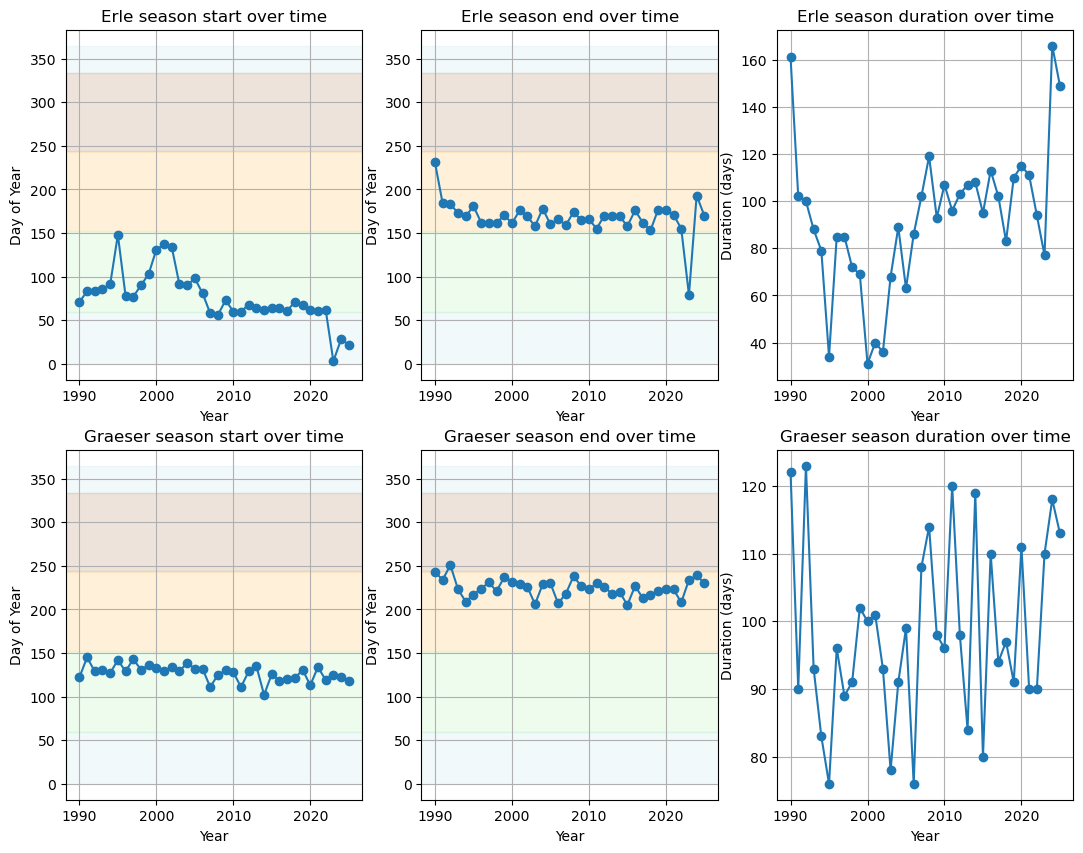

In [21]:
# Plot metrics over the years of Erle and Graeser

fig, axs = plt.subplots(2, 3, figsize=(13,10))

axs[0,0].plot(erle_metrics.index, erle_metrics["season_start_doy"], marker="o")
axs[0,0].set_title("Erle season start over time")
axs[0,0].set_xlabel("Year")
axs[0,0].set_ylabel("Day of Year")
axs[0,0].grid("True")

axs[0,1].plot(erle_metrics.index, erle_metrics["season_end_doy"], marker="o")
axs[0,1].set_title("Erle season end over time")
axs[0,1].set_xlabel("Year")
axs[0,1].set_ylabel("Day of Year")
axs[0,1].grid("True")

axs[0,2].plot(erle_metrics.index, erle_metrics["season_duration_days"], marker="o")
axs[0,2].set_title("Erle season duration over time")
axs[0,2].set_xlabel("Year")
axs[0,2].set_ylabel("Duration (days)")
axs[0,2].grid("True")

axs[1,0].plot(graeser_metrics.index, graeser_metrics["season_start_doy"], marker="o")
axs[1,0].set_title("Graeser season start over time")
axs[1,0].set_xlabel("Year")
axs[1,0].set_ylabel("Day of Year")
axs[1,0].grid("True")

axs[1,1].plot(graeser_metrics.index, graeser_metrics["season_end_doy"], marker="o")
axs[1,1].set_title("Graeser season end over time")
axs[1,1].set_xlabel("Year")
axs[1,1].set_ylabel("Day of Year")
axs[1,1].grid("True")

axs[1,2].plot(graeser_metrics.index, graeser_metrics["season_duration_days"], marker="o")
axs[1,2].set_title("Graeser season duration over time")
axs[1,2].set_xlabel("Year")
axs[1,2].set_ylabel("Duration (days)")
axs[1,2].grid("True")

# add season background (standard meteorological seasons ~90 days per season)
alpha = 0.15  # light shading

for ax in [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]:
    ax.axhspan(0, 59, color='lightblue', alpha=alpha) # winter
    ax.axhspan(335, 365, color='lightblue', alpha=alpha)
    ax.axhspan(60, 151, color='lightgreen', alpha=alpha) # spring
    ax.axhspan(152, 243, color='orange', alpha=alpha) # summer
    ax.axhspan(244, 334, color='saddlebrown', alpha=alpha) # autumn

    
plt.show()

Observations from plots:
- Erle pollen has a downward trend for its season start (with occasional anomalies), the season end stays relatively stable -> duration appears to increase since the 2000's
- Graeser pollen has a slight downward trend for its season start, season end stays relatively stable but duration seems a bit noisy

Overall, the plots suggest that Erle pollen is strongly influenced by changing climatic conditions, particularly through a shift toward earlier season onset. In contrast, Graeser pollen shows a weaker response, with only a modest shift in season timing (start). For both pollen types, season duration exhibits substantial inter-annual variability, indicating that short-term weather conditions play an important role in shaping pollen dynamics.

In [22]:
# We implement the Mann-Kendall trend test 
from scipy.stats import theilslopes
import pymannkendall as mk

def trend_summary(series):
    clean = series.dropna()
    result = mk.original_test(clean)
    slope, intercept, _, _ = theilslopes(clean.values, clean.index.values)
    return {
        "trend":         result.trend,
        "tau":           result.Tau,
        "p_value":       result.p,
        "slope_per_year": slope
    }

In [23]:
# Now we will run the Mann-Kendall trend test on each metric of the pollen
for name, metrics in [("Erle", erle_metrics), ("Graeser", graeser_metrics)]:
    print(f"\nMK-Test results for {name}")
    for col in ["season_start_doy", "season_end_doy", "season_duration_days"]:
        res = trend_summary(metrics[col])
        
        print(f"---{col}---")
        print(f"trend = {res['trend']}")
        print(f"tau = {res['tau']:.3f}")
        print(f"p-value = {res['p_value']:.4f}")
        print(f"slope = {res['slope_per_year']:.3f} per year")


MK-Test results for Erle
---season_start_doy---
trend = decreasing
tau = -0.489
p-value = 0.0000
slope = -1.447 per year
---season_end_doy---
trend = no trend
tau = -0.192
p-value = 0.1015
slope = -0.299 per year
---season_duration_days---
trend = increasing
tau = 0.335
p-value = 0.0042
slope = 1.131 per year

MK-Test results for Graeser
---season_start_doy---
trend = decreasing
tau = -0.344
p-value = 0.0032
slope = -0.437 per year
---season_end_doy---
trend = no trend
tau = -0.140
p-value = 0.2352
slope = -0.250 per year
---season_duration_days---
trend = no trend
tau = 0.119
p-value = 0.3129
slope = 0.268 per year


Observations (Erle):
- season start: tau < 0 -> clear decreasing trend, p-value = 0 -> highly significant, slope = -1.447 days/year -> season starts earlier at a rate of about 1.45 days per year
- season end: tau is close to 0 -> weak to no trend; p-value ~ 0.1 -> trend not statistically significant; slope ~ -0.3 -> season end change is small
- season duration: tau > 0 -> clear increasing trend, p-value = 0.0042 -> statistically significant, slope ~ 1.131 -> season length increases at a rate of about 1 day per year

Observations (Graeser):
- season start: tau < 0 -> decreasing trend, p-value = 0.0032 -> statistically significant, slope = -0.437 days/year -> moderate shift towards earlier season (weaker than for Erle)
- season end: tau is closer to 0 -> little to no trend; p-value ~ 0.24 -> trend not significant; slope ~ -0.25 -> season end change is small
- season duration: tau > 0 -> little to no trend, p-value = 0.313 -> trend not statistically significant, slope ~ 0.27 -> season length change is small

Overall, the results indicate a strong shift toward earlier onset and increasing duration for Erle, while Graeser shows a weaker responce, with only the season start showing any kind of significant trend.

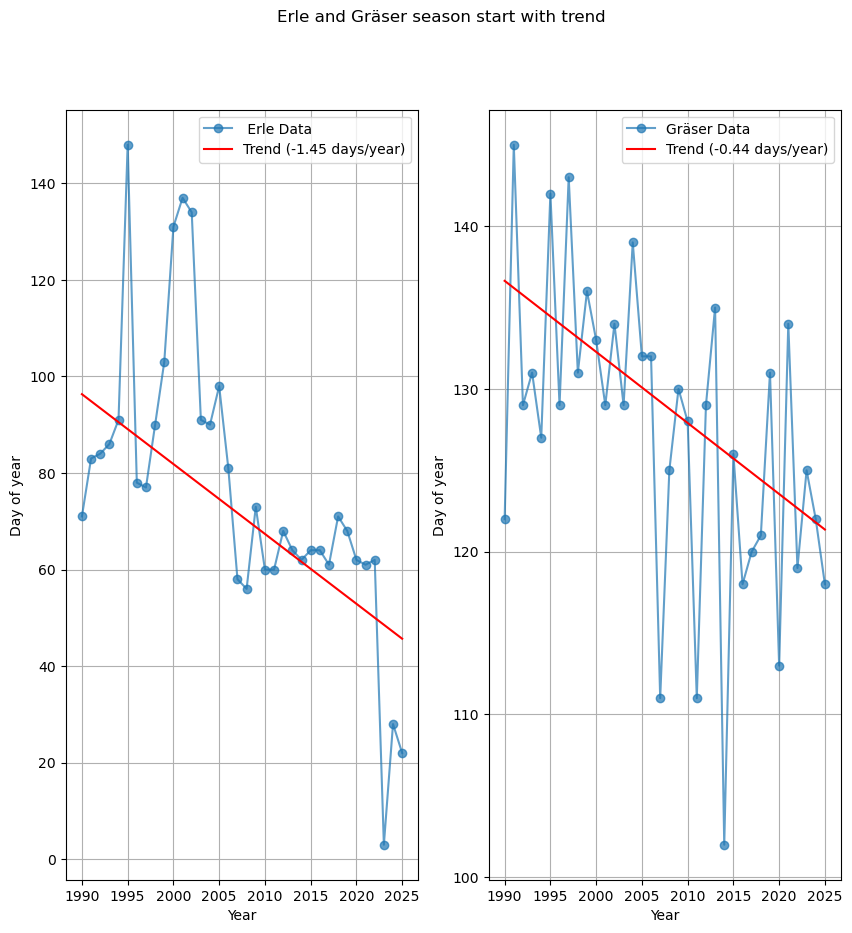

In [24]:
# Plot results from MK trend Test:

erle_x = erle_metrics.index.values
erle_y = erle_metrics["season_start_doy"].values

graeser_x = graeser_metrics.index.values
graeser_y = graeser_metrics["season_start_doy"].values

# Theil-Sen trend line
erle_slope, erle_intercept, _, _ = theilslopes(erle_y, erle_x)
graeser_slope, graeser_intercept, _, _ = theilslopes(graeser_y, graeser_x)

fig, axs = plt.subplots(1,2, figsize=(10,10))
fig.suptitle("Erle and Gräser season start with trend")

axs[0].plot(erle_x, erle_y, "o-", label=" Erle Data", alpha=0.7)
axs[0].plot(erle_x, erle_intercept + erle_slope * erle_x, color="red", label=f"Trend ({erle_slope:.2f} days/year)")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Day of year")
axs[0].legend()
axs[0].grid()

axs[1].plot(graeser_x, graeser_y, "o-", label="Gräser Data", alpha=0.7)
axs[1].plot(graeser_x, graeser_intercept + graeser_slope * graeser_x, color="red", label=f"Trend ({graeser_slope:.2f} days/year)")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Day of year")
axs[1].legend()
axs[1].grid()

plt.show()

Observations:
- Erle: strong downward slope, consistent shift earlier
- Graeser: still downward but weaker and noisier